# Fixed-σ (legacy) vs. per-diagram adaptive-σ persistence images

`PersistenceImager` used to take one hand-picked `sigma` shared by every diagram and
every homology dimension. It now computes `sigma` per (diagram, dim) from that
diagram's own persistence spread (`sigma_frac * median` or `* IQR` of its
off-diagonal persistences, floored at `min_sigma_pixels` pixels) -- see
`cloudforger.vectorizers.persistence_image.PersistenceImager.transform`.

This notebook re-images the **same clouds** -- via their already-computed diagrams in
`data/legacy/nested_thomas/dtm_k{5,10,15}/diagrams.pkl` -- with the new adaptive
imager, so the comparison to the legacy `persistence_image.pkl` bundles is a true
paired before/after on identical input, not a comparison across two differently
generated datasets (the current `data/nested_thomas/` was regenerated with a
different design/sample count and isn't directly comparable this way).

Two comparisons are run:

1. **As-shipped**: legacy bundle vs. the imager exactly as `scripts/featurize.py`
   builds it today (`resolution=64`, `weight=False`, adaptive sigma).
2. **Sigma-only ablation**: legacy `resolution`/`weight` held fixed, only the sigma
   mechanism changes -- isolates what the adaptive-sigma change itself does, since
   the as-shipped config also happens to change resolution and turn point-weighting
   off, which would otherwise confound the mass/dynamic-range comparisons below.

Nothing here is a reimplementation of the pipeline -- it calls
`cloudforger.vectorizers`/`cloudforger.core.records` directly and only duplicates
the tiny sigma formula itself, for diagnostic inspection (`PersistenceImager` doesn't
expose the per-diagram sigma it used internally).

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from cloudforger.core.io import load_pickle
from cloudforger.core.records import load_diagrams
from cloudforger.core.calibration import axis_bounds, calibrate
from cloudforger.vectorizers.calibrated import build_calibrated_imager
from cloudforger.vectorizers.persistence_image import PersistenceImager
from cloudforger.vectorizers.multi_channel import MultiChannelImager

K_VALUES = [5, 10, 15]
HOMOLOGY_DIMS = (0, 1)
LEGACY_ROOT = ROOT / "data" / "legacy" / "nested_thomas"

# Fixed categorical assignment used throughout: legacy is always OLD, every
# adaptive-sigma variant is always NEW.
OLD = "#2a78d6"  # legacy, fixed sigma
NEW = "#eb6834"  # adaptive sigma

In [2]:
legacy_diagrams = {}
legacy_pi = {}
for k in K_VALUES:
    k_dir = LEGACY_ROOT / f"dtm_k{k}"
    diagrams, _bundle = load_diagrams(k_dir / "diagrams.pkl")
    legacy_diagrams[k] = diagrams
    legacy_pi[k] = load_pickle(k_dir / "persistence_image.pkl")
    p0 = legacy_pi[k]["imager_params"][0]
    print(f"k={k}: {len(diagrams)} diagrams, legacy PI resolution={p0['resolution']}, "
          f"sigma={p0['sigma']}, weight_fn={p0['weight_fn']}")

k=5: 846 diagrams, legacy PI resolution=128, sigma=0.05, weight_fn=linear_weight
k=10: 846 diagrams, legacy PI resolution=128, sigma=0.05, weight_fn=linear_weight
k=15: 841 diagrams, legacy PI resolution=128, sigma=0.05, weight_fn=linear_weight


**Alignment check.** `diagrams.pkl` and the legacy `persistence_image.pkl` aren't
guaranteed to cover the same subset of clouds -- confirmed below: `k=5` matches
exactly (846/846, same order), but `k=10` and `k=15` don't (the legacy PI bundle is
missing several clouds that are present in the current `diagrams.pkl`). Any
same-cloud comparison below aligns by `seed`, not by list position, so it's correct
regardless of which `k` is in play.

In [3]:
def align_to_diagrams(diagrams, pi_bundle):
    """Return (idx_into_diagrams, reordered_image_tensors) for the seeds common to
    both diagrams and pi_bundle, so per-sample comparisons are guaranteed same-cloud
    even when the legacy PI bundle covers a different subset of diagrams.pkl."""
    pi_seed_to_row = {s: i for i, s in enumerate(pi_bundle["seeds"])}
    keep_idx = np.array([i for i, d in enumerate(diagrams) if d.seed in pi_seed_to_row])
    pi_rows = [pi_seed_to_row[diagrams[i].seed] for i in keep_idx]
    aligned_tensors = {
        dim: pi_bundle["image_tensors"][dim][pi_rows] for dim in pi_bundle["homology_dims"]
    }
    return keep_idx, aligned_tensors


align_idx = {}      # k -> positions into legacy_diagrams[k] / ablation_pi[k] / asshipped_pi[k]
legacy_aligned = {}  # k -> legacy image_tensors reordered to match align_idx[k]
for k in K_VALUES:
    idx, tensors = align_to_diagrams(legacy_diagrams[k], legacy_pi[k])
    align_idx[k] = idx
    legacy_aligned[k] = tensors
    print(f"k={k}: {len(idx)}/{len(legacy_diagrams[k])} diagrams have a matching legacy PI row")

k=5: 846/846 diagrams have a matching legacy PI row
k=10: 841/846 diagrams have a matching legacy PI row
k=15: 825/841 diagrams have a matching legacy PI row


## 1. As-shipped comparison

Build the imager exactly the way `scripts/featurize.py` does today
(`build_calibrated_imager`, `resolution=64`, `sigma_frac=0.1`, `sigma_stat="median"`),
applied to the *legacy* diagrams so it's directly next to the legacy bundle.

In [4]:
asshipped_pi = {}
for k in K_VALUES:
    diagrams = legacy_diagrams[k]
    imager = build_calibrated_imager(
        diagrams, homology_dims=HOMOLOGY_DIMS, resolution=64,
        sigma_frac=0.1, sigma_stat="median", verbose=False,
    )
    images = [imager.transform(d) for d in diagrams]
    asshipped_pi[k] = {
        "imager_params": imager.params,
        "image_tensors": {dim: np.stack([im[dim] for im in images]) for dim in HOMOLOGY_DIMS},
    }
    print(f"k={k}: as-shipped PI computed, resolution={imager.params[0]['resolution']}")

k=5: as-shipped PI computed, resolution=64
k=10: as-shipped PI computed, resolution=64
k=15: as-shipped PI computed, resolution=64


In [5]:
for k in K_VALUES:
    print(f"--- k={k} ---")
    for dim in HOMOLOGY_DIMS:
        old_p = legacy_pi[k]["imager_params"][dim]
        new_p = asshipped_pi[k]["imager_params"][dim]
        print(f"  H{dim} old: resolution={old_p['resolution']:>3}  sigma={old_p['sigma']:.4f} (fixed)  "
              f"weight_fn={old_p['weight_fn']}")
        print(f"  H{dim} new: resolution={new_p['resolution']:>3}  "
              f"sigma_frac={new_p['sigma_frac']} sigma_stat={new_p['sigma_stat']!r} "
              f"(per-diagram, floor={new_p['min_sigma_pixels']}px)  weight_fn={new_p['weight_fn']}")

--- k=5 ---
  H0 old: resolution=128  sigma=0.0500 (fixed)  weight_fn=linear_weight
  H0 new: resolution= 64  sigma_frac=0.1 sigma_stat='median' (per-diagram, floor=1.0px)  weight_fn=None
  H1 old: resolution=128  sigma=0.0500 (fixed)  weight_fn=linear_weight
  H1 new: resolution= 64  sigma_frac=0.1 sigma_stat='median' (per-diagram, floor=1.0px)  weight_fn=None
--- k=10 ---
  H0 old: resolution=128  sigma=0.0500 (fixed)  weight_fn=linear_weight
  H0 new: resolution= 64  sigma_frac=0.1 sigma_stat='median' (per-diagram, floor=1.0px)  weight_fn=None
  H1 old: resolution=128  sigma=0.0500 (fixed)  weight_fn=linear_weight
  H1 new: resolution= 64  sigma_frac=0.1 sigma_stat='median' (per-diagram, floor=1.0px)  weight_fn=None
--- k=15 ---
  H0 old: resolution=128  sigma=0.0500 (fixed)  weight_fn=linear_weight
  H0 new: resolution= 64  sigma_frac=0.1 sigma_stat='median' (per-diagram, floor=1.0px)  weight_fn=None
  H1 old: resolution=128  sigma=0.0500 (fixed)  weight_fn=linear_weight
  H1 new: 

**Caveat before reading anything below as "the sigma effect":** the as-shipped config
differs from legacy in three ways at once -- `resolution` (128 -> 64), `weight_fn`
(legacy always weighted by persistence; as-shipped's default is unweighted), and
`sigma` (fixed -> adaptive). Resolution alone changes the raw pixel-sum scale
(`transform` sums the kernel evaluated at each grid node rather than integrating
per pixel area, so going from 128x128 to 64x64 shrinks the raw sum by roughly 4x
independent of sigma), and the weighting switch changes it again. Section 2 isolates
just the sigma change so those two confounds don't leak into the interpretation.

## 2. Sigma-only ablation

Hold `resolution` and `weight` at legacy's values (128, weighted) and change only the
sigma mechanism, by calling `PersistenceImager` directly with `weight=True` instead of
going through `build_calibrated_imager` (which doesn't expose a `weight` passthrough).
Bounds still come from the same `calibrate`/`axis_bounds` utilities `build_calibrated_imager`
uses internally -- this isn't a reimplementation, just skipping the wrapper for one extra
constructor argument.

In [6]:
def build_ablation_imager(diagrams, homology_dims=HOMOLOGY_DIMS, resolution=128,
                           sigma_frac=0.1, sigma_stat="median"):
    stats = calibrate(diagrams)
    imagers = {}
    for dim in homology_dims:
        birth_hi, pers_hi = axis_bounds(stats, dim)
        imagers[dim] = PersistenceImager(
            birth_range=(0.0, birth_hi), pers_range=(0.0, pers_hi),
            resolution=resolution, sigma_frac=sigma_frac, sigma_stat=sigma_stat,
            weight=True,  # match legacy's linear_weight behavior
        )
    return MultiChannelImager(imagers)


ablation_pi = {}
for k in K_VALUES:
    diagrams = legacy_diagrams[k]
    imager = build_ablation_imager(diagrams)
    images = [imager.transform(d) for d in diagrams]
    ablation_pi[k] = {
        "imager_params": imager.params,
        "image_tensors": {dim: np.stack([im[dim] for im in images]) for dim in HOMOLOGY_DIMS},
    }
    print(f"k={k}: ablation PI computed (resolution=128, weighted, adaptive sigma)")

k=5: ablation PI computed (resolution=128, weighted, adaptive sigma)
k=10: ablation PI computed (resolution=128, weighted, adaptive sigma)
k=15: ablation PI computed (resolution=128, weighted, adaptive sigma)


## 3. Does sigma actually adapt to each diagram, or is it effectively constant?

`PersistenceImager` computes sigma internally per call and doesn't return it, so this
mirrors the exact 3-line formula from `transform` (`frac * median(persistence)`,
floored at `min_sigma_pixels` pixels) purely to inspect the value it would use per
diagram, against legacy's single flat `0.05`.

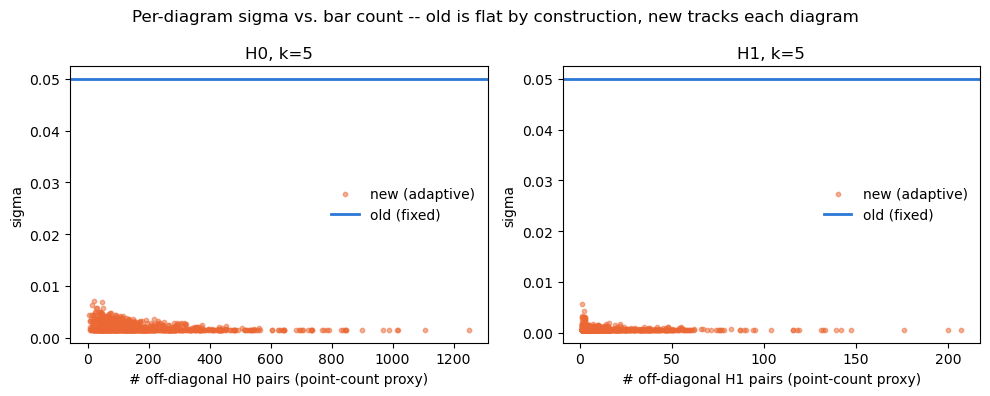

In [7]:
def per_diagram_sigma(diagram, dim, pers_range, resolution, sigma_frac=0.1,
                       sigma_stat="median", min_sigma_pixels=1.0):
    pairs = diagram.finite_pairs(dim)
    if len(pairs) == 0:
        return np.nan, 0
    persistences = pairs[:, 1] - pairs[:, 0]
    if sigma_stat == "median":
        spread = np.median(persistences)
    else:
        q1, q3 = np.percentile(persistences, [25, 75])
        spread = q3 - q1
    spread = spread if np.isfinite(spread) and spread > 0 else np.finfo(float).eps
    pixel = (pers_range[1] - pers_range[0]) / resolution
    sigma = max(sigma_frac * spread, min_sigma_pixels * pixel)
    return sigma, len(pairs)


k = 5
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, dim in zip(axes, HOMOLOGY_DIMS):
    params = ablation_pi[k]["imager_params"][dim]
    sigmas, counts = zip(*[
        per_diagram_sigma(d, dim, params["pers_range"], params["resolution"])
        for d in legacy_diagrams[k]
    ])
    counts, sigmas = np.array(counts), np.array(sigmas)
    ax.scatter(counts, sigmas, s=10, alpha=0.5, color=NEW, label="new (adaptive)")
    ax.axhline(legacy_pi[k]["imager_params"][dim]["sigma"], color=OLD, lw=2, label="old (fixed)")
    ax.set_xlabel(f"# off-diagonal H{dim} pairs (point-count proxy)")
    ax.set_ylabel("sigma")
    ax.set_title(f"H{dim}, k={k}")
    ax.legend(frameon=False)
fig.suptitle("Per-diagram sigma vs. bar count -- old is flat by construction, new tracks each diagram")
fig.tight_layout()
plt.show()

## 4. Example images: same cloud, legacy vs. sigma-only ablation

Three clouds spanning the sparsest / median / densest H0 bar count in `k=5`, so the
adaptive mechanism gets exercised at both ends of the point-count range it's meant to
be robust to.

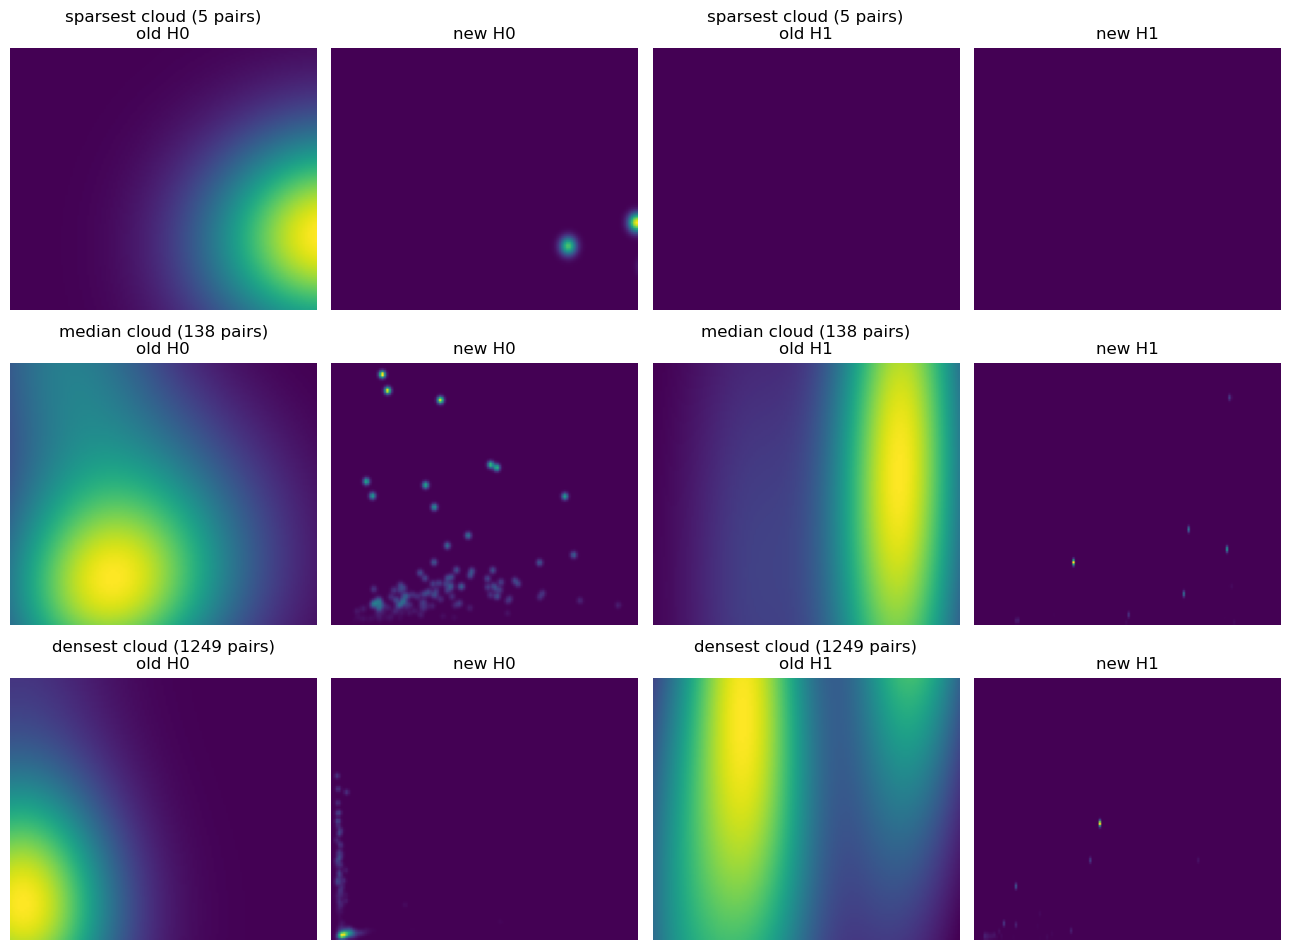

In [8]:
k = 5
idx = align_idx[k]  # positions into legacy_diagrams[k] / ablation_pi[k]
counts0 = np.array([len(legacy_diagrams[k][i].finite_pairs(0)) for i in idx])
order = np.argsort(counts0)  # positions within the aligned subset
picks = [int(order[0]), int(order[len(order) // 2]), int(order[-1])]
example_labels = ["sparsest cloud", "median cloud", "densest cloud"]

fig, axes = plt.subplots(len(picks), 4, figsize=(13, 3.2 * len(picks)))
for row, (j, label) in enumerate(zip(picks, example_labels)):
    full_i = idx[j]  # position into legacy_diagrams[k] / ablation_pi[k]
    for col, dim in enumerate(HOMOLOGY_DIMS):
        old_img = legacy_aligned[k][dim][j]
        new_img = ablation_pi[k]["image_tensors"][dim][full_i]
        ax_old, ax_new = axes[row, col * 2], axes[row, col * 2 + 1]
        ax_old.imshow(old_img, cmap="viridis", aspect="auto")
        ax_old.set_title(f"{label} ({counts0[j]} pairs)\nold H{dim}")
        ax_old.axis("off")
        ax_new.imshow(new_img, cmap="viridis", aspect="auto")
        ax_new.set_title(f"new H{dim}")
        ax_new.axis("off")
fig.tight_layout()
plt.show()

## 5. Distributional comparison: image mass, legacy vs. sigma-only ablation

`resolution` and `weight` are matched to legacy here (Section 2's ablation), so any
shift in the mass distribution below is attributable to the sigma mechanism itself,
not to the as-shipped config's incidental resolution/weight changes.

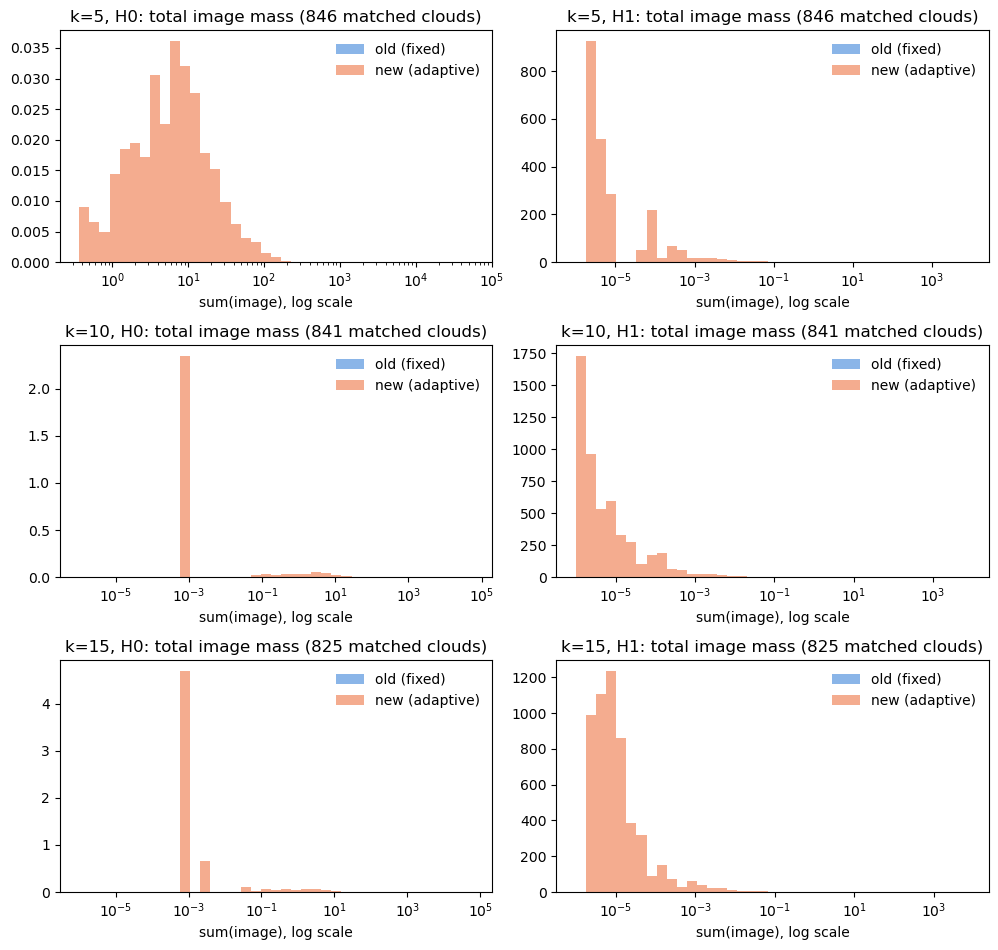

In [9]:
fig, axes = plt.subplots(len(K_VALUES), 2, figsize=(10, 3.2 * len(K_VALUES)))
for row, k in enumerate(K_VALUES):
    idx = align_idx[k]
    for col, dim in enumerate(HOMOLOGY_DIMS):
        old_mass = legacy_aligned[k][dim].sum(axis=(1, 2))
        new_mass = ablation_pi[k]["image_tensors"][dim][idx].sum(axis=(1, 2))
        # Log-x: the two mechanisms produce mass on very different absolute
        # scales (tighter kernels sum to far less raw pixel mass), so a linear
        # axis collapses one series to an invisible sliver.
        bins = np.logspace(
            np.log10(min(old_mass.min(), new_mass.min()) + 1e-6),
            np.log10(max(old_mass.max(), new_mass.max())),
            40,
        )
        ax = axes[row, col]
        ax.hist(old_mass, bins=bins, color=OLD, alpha=0.55, label="old (fixed)", density=True)
        ax.hist(new_mass, bins=bins, color=NEW, alpha=0.55, label="new (adaptive)", density=True)
        ax.set_xscale("log")
        ax.set_title(f"k={k}, H{dim}: total image mass ({len(idx)} matched clouds)")
        ax.set_xlabel("sum(image), log scale")
        ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 6. Point-count coupling, quantified

The original motivation for adaptive sigma was that a fixed sigma makes image
content act as a proxy for point count rather than for persistence structure
itself. Correlate `log(total image mass)` with `log(# off-diagonal pairs)` --
a lower correlation for the adaptive images is direct evidence of reduced
point-count coupling, not just a qualitative impression.

In [10]:
print(f"{'k':>4} {'dim':>4} {'corr(log count, log mass) old':>32} {'new':>10}")
for k in K_VALUES:
    idx = align_idx[k]
    for dim in HOMOLOGY_DIMS:
        counts = np.array([len(legacy_diagrams[k][i].finite_pairs(dim)) for i in idx])
        old_mass = legacy_aligned[k][dim].sum(axis=(1, 2))
        new_mass = ablation_pi[k]["image_tensors"][dim][idx].sum(axis=(1, 2))
        mask = counts > 0
        old_r = np.corrcoef(np.log1p(counts[mask]), np.log1p(old_mass[mask]))[0, 1]
        new_r = np.corrcoef(np.log1p(counts[mask]), np.log1p(new_mass[mask]))[0, 1]
        print(f"{k:>4} {dim:>4} {old_r:>32.3f} {new_r:>10.3f}")

   k  dim    corr(log count, log mass) old        new
   5    0                            0.731      0.361
   5    1                            0.832      0.345
  10    0                            0.798      0.384
  10    1                            0.852      0.418
  15    0                            0.848      0.421
  15    1                            0.867      0.457


## Reading this notebook

- Section 3 is the core mechanism check: a flat line (old) vs. a cloud of points
  that actually varies with bar count (new) confirms sigma is no longer a fixed
  proxy constant -- if the new scatter is *also* flat, `sigma_frac`/`sigma_stat`
  aren't doing anything and the change isn't working as intended.
- Section 4 is a qualitative eyeball check on real images at the extremes of point
  count -- look for over-smoothing (blobby, no structure) on sparse clouds and
  under-smoothing (speckled, noisy) on dense ones under the old fixed sigma, and
  whether the new one looks more consistent across both.
- Section 5 is a distributional sanity check, and deliberately uses the ablation
  (Section 2), not the as-shipped config (Section 1), to avoid conflating the sigma
  effect with the resolution/weight changes that happened to ship alongside it.
- Section 6 is the real test of the design motivation: a markedly lower
  `corr(log count, log mass)` for the new column is quantitative evidence that
  the adaptive images are less driven by point count than the old fixed-sigma
  ones; if the two columns are close, the adaptive mechanism isn't buying much
  decoupling in practice on this data.